Training Q-Learning Agent with Card Counting...
Q-Learning Episode 10000 completed
Q-Learning Episode 20000 completed
Q-Learning Episode 30000 completed
Q-Learning Episode 40000 completed
Q-Learning Episode 50000 completed
Q-Learning Episode 60000 completed
Q-Learning Episode 70000 completed
Q-Learning Episode 80000 completed
Q-Learning Episode 90000 completed
Q-Learning Episode 100000 completed
Q-Learning with Card Counting Training completed.

Training Q-Learning Agent without Card Counting...
Q-Learning Episode 10000 completed
Q-Learning Episode 20000 completed
Q-Learning Episode 30000 completed
Q-Learning Episode 40000 completed
Q-Learning Episode 50000 completed
Q-Learning Episode 60000 completed
Q-Learning Episode 70000 completed
Q-Learning Episode 80000 completed
Q-Learning Episode 90000 completed
Q-Learning Episode 100000 completed
Q-Learning without Card Counting Training completed.

Training SARSA Agent with Card Counting...
SARSA Episode 10000 completed
SARSA Episode 20000 c

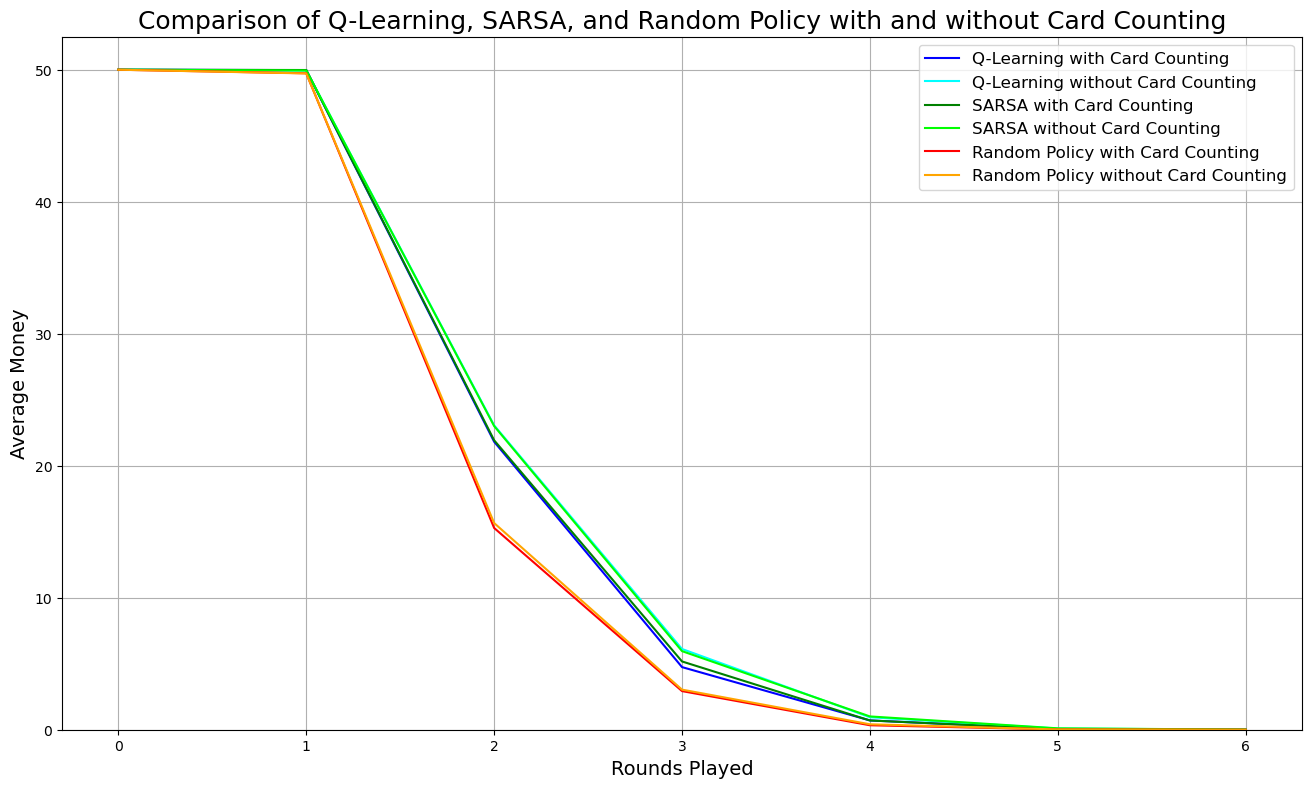

In [1]:
import numpy as np
from collections import defaultdict
import gymnasium as gym
import matplotlib.pyplot as plt
import pickle

# Define the default Q-value function
def default_q_value():
    return np.zeros(2)  # Two actions: 0 (Stand), 1 (Hit)

# Q-Learning Agent
class QLearningAgent:
    def __init__(
        self,
        learning_rate=0.1,
        discount_factor=0.99,
        epsilon=1.0,
        epsilon_decay=0.9999,
        min_epsilon=0.01
    ):
        self.q_values = defaultdict(default_q_value)
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.choice([0, 1])
        else:
            action = np.argmax(self.q_values[state])
        return action

    def update(self, state, action, reward, next_state, done):
        current_q = self.q_values[state][action]
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * np.max(self.q_values[next_state])
        self.q_values[state][action] += self.lr * (target_q - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

    def set_epsilon(self, value):
        self.epsilon = value

# SARSA Agent
class SARSAAgent:
    def __init__(
        self,
        learning_rate=0.1,
        discount_factor=0.99,
        epsilon=1.0,
        epsilon_decay=0.9999,
        min_epsilon=0.01
    ):
        self.q_values = defaultdict(default_q_value)
        self.lr = learning_rate
        self.gamma = discount_factor
        self.epsilon = epsilon
        self.epsilon_decay = epsilon_decay
        self.min_epsilon = min_epsilon

    def get_action(self, state):
        if np.random.random() < self.epsilon:
            action = np.random.choice([0, 1])
        else:
            action = np.argmax(self.q_values[state])
        return action

    def update(self, state, action, reward, next_state, next_action, done):
        current_q = self.q_values[state][action]
        if done:
            target_q = reward
        else:
            target_q = reward + self.gamma * self.q_values[next_state][next_action]
        self.q_values[state][action] += self.lr * (target_q - current_q)

    def decay_epsilon(self):
        self.epsilon = max(self.min_epsilon, self.epsilon * self.epsilon_decay)

    def set_epsilon(self, value):
        self.epsilon = value

# Random Agent
class RandomAgent:
    def get_action(self, state):
        return np.random.choice([0, 1])

# Blackjack Environment
class BlackjackEnv(gym.Env):
    def __init__(self, render_mode=None, natural=False, sab=False, total_decks=5, include_count=False):
        super(BlackjackEnv, self).__init__()
        self.include_count = include_count
        self.action_space = gym.spaces.Discrete(2)  # 0: Stand, 1: Hit

        if self.include_count:
            self.observation_space = gym.spaces.Tuple(
                (
                    gym.spaces.Discrete(32),   # Player's current sum (0-31)
                    gym.spaces.Discrete(11),   # Dealer's visible card (1-10)
                    gym.spaces.Discrete(2),    # Usable Ace (0: No, 1: Yes)
                    gym.spaces.Discrete(101),  # Player's money (0-100)
                    gym.spaces.Discrete(41),   # Running Count shifted from [-20,20] to [0,40]
                    gym.spaces.Discrete(21)     # Remaining Decks (0-20)
                )
            )
        else:
            self.observation_space = gym.spaces.Tuple(
                (
                    gym.spaces.Discrete(32),   # Player's current sum (0-31)
                    gym.spaces.Discrete(11),   # Dealer's visible card (1-10)
                    gym.spaces.Discrete(2),    # Usable Ace (0: No, 1: Yes)
                    gym.spaces.Discrete(101)   # Player's money (0-100)
                )
            )

        self.natural = natural
        self.sab = sab
        self.render_mode = render_mode
        self.running_count = 0
        self.betting_unit = 1
        self.money = 50
        self.current_bet = 1
        one_suite = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 10, 10, 10]
        self.original_deck = one_suite * 4 * total_decks
        self.deck = self.original_deck.copy()

    def step(self, action):
        assert self.action_space.contains(action), f"Invalid Action: {action}"
        if action == 1:
            self.player.append(self.draw_card())
            if self.is_bust(self.player):
                terminated = True
                reward = -1.0
            else:
                terminated = False
                reward = 0.0
        else:
            terminated = True
            while self.sum_hand(self.dealer) < 17:
                self.dealer.append(self.draw_card())
            reward = self.cmp(self.score(self.player), self.score(self.dealer))
            if self.sab and self.is_natural(self.player) and not self.is_natural(self.dealer):
                reward = 1.0
            elif not self.sab and self.natural and self.is_natural(self.player) and reward == 1.0:
                reward = 1.5

        # Update money and ensure it doesn't go below 0
        self.money = max(self.money + reward * self.current_bet, 0)
        return self._get_obs(), reward, terminated, {}

    def _get_obs(self):
        if self.include_count:
            shifted_count = self.running_count + 20
            shifted_count = np.clip(shifted_count, 0, 40)
            remaining_decks = self.getRemainingDecks()
            return (
                self.sum_hand(self.player),
                self.dealer[0],
                int(self.usable_ace(self.player)),
                self.money,
                shifted_count,
                remaining_decks
            )
        else:
            return (
                self.sum_hand(self.player),
                self.dealer[0],
                int(self.usable_ace(self.player)),
                self.money
            )

    def reset(self, seed=None):
        super().reset(seed=seed)
        self.money = 50
        self.deck = self.original_deck.copy()
        self.running_count = 0
        return self.new_round()

    def new_round(self):
        self.dealer = self.draw_hand()
        self.player = self.draw_hand()
        return self._get_obs()

    def draw_card(self):
        if len(self.deck) == 0:
            raise ValueError("The deck is empty!")
        card = self.deck.pop(np.random.randint(len(self.deck)))
        if self.include_count:
            if card in [1, 10]:
                self.running_count -= 1
            elif 2 <= card <= 6:
                self.running_count += 1
        return card

    def draw_hand(self):
        return [self.draw_card(), self.draw_card()]

    def getRemainingDecks(self):
        return min(round(len(self.deck) / 52 * 2) / 2, 20)

    @staticmethod
    def cmp(a, b):
        return float(a > b) - float(a < b)

    @staticmethod
    def usable_ace(hand):
        return 1 in hand and sum(hand) + 10 <= 21

    @staticmethod
    def sum_hand(hand):
        if BlackjackEnv.usable_ace(hand):
            return sum(hand) + 10
        return sum(hand)

    @staticmethod
    def is_bust(hand):
        return BlackjackEnv.sum_hand(hand) > 21

    @staticmethod
    def score(hand):
        return 0 if BlackjackEnv.is_bust(hand) else BlackjackEnv.sum_hand(hand)

    @staticmethod
    def is_natural(hand):
        return sorted(hand) == [1, 10]

# Training Q-Learning Agent
def train_q_learning(env, agent, num_episodes):
    for episode in range(1, num_episodes + 1):
        state = env.reset()
        done = False
        while not done:
            action = agent.get_action(state)
            next_state, reward, done, _ = env.step(action)
            agent.update(state, action, reward, next_state, done)
            state = next_state
        agent.decay_epsilon()
        if episode % 10000 == 0:
            print(f"Q-Learning Episode {episode} completed")
    return

# Training SARSA Agent
def train_sarsa(env, agent, num_episodes):
    for episode in range(1, num_episodes + 1):
        state = env.reset()
        action = agent.get_action(state)
        done = False
        while not done:
            next_state, reward, done, _ = env.step(action)
            next_action = agent.get_action(next_state) if not done else None
            agent.update(state, action, reward, next_state, next_action, done)
            state = next_state
            action = next_action
        agent.decay_epsilon()
        if episode % 10000 == 0:
            print(f"SARSA Episode {episode} completed")
    return

# Running Random Policy without Card Counting
def run_random_policy(env, num_episodes):
    money_per_episode = []
    rounds_per_episode = []
    random_agent = RandomAgent()
    for episode in range(1, num_episodes + 1):
        state = env.reset()
        done = False
        money_history = [env.money]
        rounds = 0
        while not done:
            action = random_agent.get_action(state)
            next_state, reward, done, _ = env.step(action)
            state = next_state
            money_history.append(env.money)
            rounds += 1
            if env.getRemainingDecks() < 1 or env.money <= 0:
                done = True
        money_per_episode.append(money_history)
        rounds_per_episode.append(rounds)
        if episode % 10000 == 0:
            print(f"Random Policy Episode {episode} completed")
    return money_per_episode, rounds_per_episode

# Function to run evaluation with greedy policy (epsilon=0)
def evaluate_agent(env, agent, num_episodes):
    money_per_episode = []
    rounds_per_episode = []
    # Set epsilon to 0 for greedy policy
    agent.set_epsilon(0.0)
    for episode in range(1, num_episodes + 1):
        state = env.reset()
        done = False
        money_history = [env.money]
        rounds = 0
        while not done:
            action = agent.get_action(state)
            next_state, reward, done, _ = env.step(action)
            state = next_state
            money_history.append(env.money)
            rounds += 1
            if env.getRemainingDecks() < 1 or env.money <= 0:
                done = True
        money_per_episode.append(money_history)
        rounds_per_episode.append(rounds)
        if episode % 10000 == 0:
            print(f"Evaluation Episode {episode} completed")
    # Reset epsilon after evaluation
    agent.set_epsilon(agent.min_epsilon)
    return money_per_episode, rounds_per_episode

# Function to pad money lists to the maximum number of rounds
def pad_money(money_list, max_rounds):
    padded_money = []
    for money in money_list:
        if len(money) < max_rounds +1:
            # Pad with 0s after exhaustion
            padded = money + [0] * (max_rounds +1 - len(money))
            padded_money.append(padded)
        else:
            padded_money.append(money[:max_rounds +1])
    return np.array(padded_money)

# Main script
if __name__ == "__main__":
    num_training_episodes = 100000
    num_evaluation_episodes = 10000
    num_random_episodes = 100000  # For Random Policy runs

    # Initialize environments
    # 1. Q-Learning with Card Counting
    env_q_counting = BlackjackEnv(include_count=True)
    # 2. Q-Learning without Card Counting
    env_q_no_counting = BlackjackEnv(include_count=False)
    # 3. SARSA with Card Counting
    env_sarsa_counting = BlackjackEnv(include_count=True)
    # 4. SARSA without Card Counting
    env_sarsa_no_counting = BlackjackEnv(include_count=False)
    # 5. Random Policy with Card Counting
    env_random_counting = BlackjackEnv(include_count=True)
    # 6. Random Policy without Card Counting
    env_random_no_counting = BlackjackEnv(include_count=False)

    # Initialize agents
    agent_q_counting = QLearningAgent()
    agent_q_no_counting = QLearningAgent()
    agent_sarsa_counting = SARSAAgent()
    agent_sarsa_no_counting = SARSAAgent()
    # Random Agent doesn't need to be initialized with Q or SARSA agents

    # Train Q-Learning Agent with Card Counting
    print("Training Q-Learning Agent with Card Counting...")
    train_q_learning(env_q_counting, agent_q_counting, num_training_episodes)
    print("Q-Learning with Card Counting Training completed.\n")

    # Train Q-Learning Agent without Card Counting
    print("Training Q-Learning Agent without Card Counting...")
    train_q_learning(env_q_no_counting, agent_q_no_counting, num_training_episodes)
    print("Q-Learning without Card Counting Training completed.\n")

    # Train SARSA Agent with Card Counting
    print("Training SARSA Agent with Card Counting...")
    train_sarsa(env_sarsa_counting, agent_sarsa_counting, num_training_episodes)
    print("SARSA with Card Counting Training completed.\n")

    # Train SARSA Agent without Card Counting
    print("Training SARSA Agent without Card Counting...")
    train_sarsa(env_sarsa_no_counting, agent_sarsa_no_counting, num_training_episodes)
    print("SARSA without Card Counting Training completed.\n")

    # Run Random Policy with Card Counting
    print("Running Random Policy with Card Counting...")
    money_random_counting, rounds_random_counting = run_random_policy(env_random_counting, num_random_episodes)
    print("Random Policy with Card Counting runs completed.\n")

    # Run Random Policy without Card Counting
    print("Running Random Policy without Card Counting...")
    money_random_no_counting, rounds_random_no_counting = run_random_policy(env_random_no_counting, num_random_episodes)
    print("Random Policy without Card Counting runs completed.\n")

    # Evaluate Q-Learning Agent with Card Counting
    print("Evaluating Q-Learning Agent with Card Counting...")
    money_q_counting_eval, rounds_q_counting_eval = evaluate_agent(env_q_counting, agent_q_counting, num_evaluation_episodes)
    print("Q-Learning with Card Counting Evaluation completed.\n")

    # Evaluate Q-Learning Agent without Card Counting
    print("Evaluating Q-Learning Agent without Card Counting...")
    money_q_no_counting_eval, rounds_q_no_counting_eval = evaluate_agent(env_q_no_counting, agent_q_no_counting, num_evaluation_episodes)
    print("Q-Learning without Card Counting Evaluation completed.\n")

    # Evaluate SARSA Agent with Card Counting
    print("Evaluating SARSA Agent with Card Counting...")
    money_sarsa_counting_eval, rounds_sarsa_counting_eval = evaluate_agent(env_sarsa_counting, agent_sarsa_counting, num_evaluation_episodes)
    print("SARSA with Card Counting Evaluation completed.\n")

    # Evaluate SARSA Agent without Card Counting
    print("Evaluating SARSA Agent without Card Counting...")
    money_sarsa_no_counting_eval, rounds_sarsa_no_counting_eval = evaluate_agent(env_sarsa_no_counting, agent_sarsa_no_counting, num_evaluation_episodes)
    print("SARSA without Card Counting Evaluation completed.\n")

    # Evaluate Random Policy with Card Counting
    print("Evaluating Random Policy with Card Counting...")
    money_random_counting_eval, rounds_random_counting_eval = run_random_policy(env_random_counting, num_evaluation_episodes)
    print("Random Policy with Card Counting Evaluation completed.\n")

    # Evaluate Random Policy without Card Counting
    print("Evaluating Random Policy without Card Counting...")
    money_random_no_counting_eval, rounds_random_no_counting_eval = run_random_policy(env_random_no_counting, num_evaluation_episodes)
    print("Random Policy without Card Counting Evaluation completed.\n")

    # Combine all evaluation data
    # Methods:
    # 1. Q-Learning with Card Counting
    # 2. Q-Learning without Card Counting
    # 3. SARSA with Card Counting
    # 4. SARSA without Card Counting
    # 5. Random Policy with Card Counting
    # 6. Random Policy without Card Counting

    # Determine maximum number of rounds across all evaluations
    max_rounds = max(
        max(len(m) for m in money_q_counting_eval),
        max(len(m) for m in money_q_no_counting_eval),
        max(len(m) for m in money_sarsa_counting_eval),
        max(len(m) for m in money_sarsa_no_counting_eval),
        max(len(m) for m in money_random_counting_eval),
        max(len(m) for m in money_random_no_counting_eval)
    ) -1  # since money_history includes initial money

    # Pad money lists
    padded_money_q_counting = pad_money(money_q_counting_eval, max_rounds)
    padded_money_q_no_counting = pad_money(money_q_no_counting_eval, max_rounds)
    padded_money_sarsa_counting = pad_money(money_sarsa_counting_eval, max_rounds)
    padded_money_sarsa_no_counting = pad_money(money_sarsa_no_counting_eval, max_rounds)
    padded_money_random_counting = pad_money(money_random_counting_eval, max_rounds)
    padded_money_random_no_counting = pad_money(money_random_no_counting_eval, max_rounds)

    # Compute mean (average) for each method
    mean_q_counting = np.mean(padded_money_q_counting, axis=0)
    mean_q_no_counting = np.mean(padded_money_q_no_counting, axis=0)
    mean_sarsa_counting = np.mean(padded_money_sarsa_counting, axis=0)
    mean_sarsa_no_counting = np.mean(padded_money_sarsa_no_counting, axis=0)
    mean_random_counting = np.mean(padded_money_random_counting, axis=0)
    mean_random_no_counting = np.mean(padded_money_random_no_counting, axis=0)

    # Plot Money vs Rounds Played
    plt.figure(figsize=(16, 9))
    rounds = np.arange(0, max_rounds +1)

    # 1. Q-Learning with Card Counting
    plt.plot(rounds, mean_q_counting, label='Q-Learning with Card Counting', color='blue')

    # 2. Q-Learning without Card Counting
    plt.plot(rounds, mean_q_no_counting, label='Q-Learning without Card Counting', color='cyan')

    # 3. SARSA with Card Counting
    plt.plot(rounds, mean_sarsa_counting, label='SARSA with Card Counting', color='green')

    # 4. SARSA without Card Counting
    plt.plot(rounds, mean_sarsa_no_counting, label='SARSA without Card Counting', color='lime')

    # 5. Random Policy with Card Counting
    plt.plot(rounds, mean_random_counting, label='Random Policy with Card Counting', color='red')

    # 6. Random Policy without Card Counting
    plt.plot(rounds, mean_random_no_counting, label='Random Policy without Card Counting', color='orange')

    # Enhanced Title and Labels
    plt.title('Comparison of Q-Learning, SARSA, and Random Policy with and without Card Counting', fontsize=18)
    plt.xlabel('Rounds Played', fontsize=14)
    plt.ylabel('Average Money', fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(True)
    plt.ylim(bottom=0)  # Prevent y-axis from going below 0

    plt.show()
